In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# read data
df = pd.read_csv('superstore_cleaned.csv', encoding='latin1')

# check
print(df.shape)
print(df.dtypes)

(9994, 27)
row_id             int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub_category      object
product_name      object
sales            float64
quantity           int64
discount         float64
profit           float64
profit_margin     object
high_discount     object
ship_days          int64
year               int64
month              int64
quarter            int64
dtype: object


In [4]:
# transfer date format
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# transfer profit_margin to number
df['profit_margin'] = pd.to_numeric(df['profit_margin'], errors='coerce')

# check
print(df[['order_date', 'ship_date', 'profit_margin']].dtypes)
print(df['profit_margin'].head())

order_date       datetime64[ns]
ship_date        datetime64[ns]
profit_margin           float64
dtype: object
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: profit_margin, dtype: float64


In [5]:
# recalculate profit_margin
df['profit_margin'] = df['profit'] / df['sales']

# check
print(df['profit_margin'].head())
print(df['profit_margin'].describe().round(4))

0    0.1600
1    0.3000
2    0.4700
3   -0.4000
4    0.1125
Name: profit_margin, dtype: float64
count    9994.0000
mean        0.1203
std         0.4668
min        -2.7500
25%         0.0750
50%         0.2700
75%         0.3625
max         0.5000
Name: profit_margin, dtype: float64


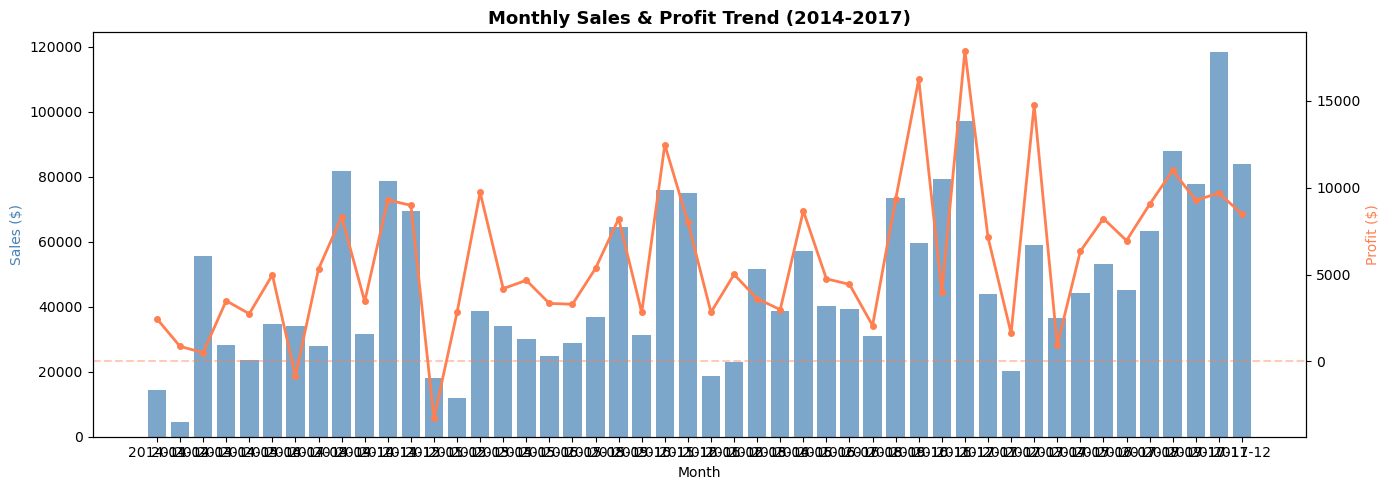

In [6]:
# Monthly Summary
monthly = df.groupby(df['order_date'].dt.to_period('M')).agg(
    sales=('sales', 'sum'),
    profit=('profit', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()
monthly['order_date'] = monthly['order_date'].astype(str)

# Graph
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly['order_date'], monthly['sales'], 
        alpha=0.7, color='steelblue', label='Sales')
ax2 = ax1.twinx()
ax2.plot(monthly['order_date'], monthly['profit'], 
         color='coral', linewidth=2, marker='o', markersize=4, label='Profit')
ax2.axhline(0, color='coral', linestyle='--', alpha=0.4)

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales ($)', color='steelblue')
ax2.set_ylabel('Profit ($)', color='coral')
plt.title('Monthly Sales & Profit Trend (2014-2017)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Discount group
bins = [-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']
df['discount_band'] = pd.cut(df['discount'], bins=bins, labels=labels)

# Summary by Category and Discount Range
discount_analysis = df.groupby(['category', 'discount_band'], observed=True).agg(
    order_count=('order_id', 'count'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    profit_margin=('profit_margin', 'mean')
).reset_index()

print(discount_analysis)

           category discount_band  order_count  total_sales  total_profit  \
0         Furniture            0%          836  256025.2700    58133.0764   
1         Furniture         1-10%           76   46634.2470     7111.0119   
2         Furniture        11-20%          667  244189.5375     7684.9406   
3         Furniture        21-30%          222   99470.3500   -10695.3169   
4         Furniture        31-50%          167   86576.3088   -33942.8446   
5         Furniture          >50%          153    9104.0820    -9839.5946   
6   Office Supplies            0%         3129  442150.0000   130506.1064   
7   Office Supplies         1-10%           16    4324.1490     1086.0808   
8   Office Supplies        11-20%         2201  233049.7360    38038.7512   
9   Office Supplies          >50%          680   39523.1470   -47140.1376   
10       Technology            0%          833  389733.2000   132348.4204   
11       Technology         1-10%            2    3410.9550      832.0843   

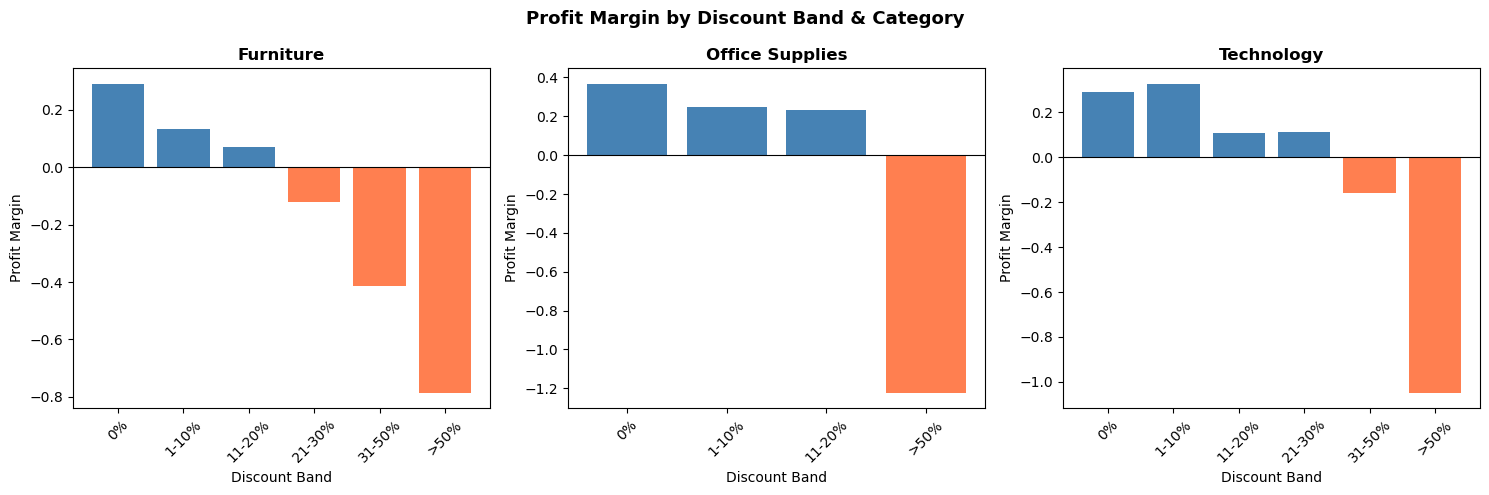

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

categories = ['Furniture', 'Office Supplies', 'Technology']
colors = ['steelblue', 'coral']

for i, cat in enumerate(categories):
    data = discount_analysis[discount_analysis['category'] == cat]
    bars = axes[i].bar(data['discount_band'], data['profit_margin'],
                       color=['steelblue' if x >= 0 else 'coral' 
                              for x in data['profit_margin']])
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].set_title(cat, fontweight='bold')
    axes[i].set_xlabel('Discount Band')
    axes[i].set_ylabel('Profit Margin')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Profit Margin by Discount Band & Category', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Calculate Raw RFM Values
snapshot = df['order_date'].max() + pd.DateOffset(1)

rfm = df.groupby('customer_id').agg(
    customer_name=('customer_name', 'first'),
    segment=('segment', 'first'),
    recency=('order_date', lambda x: (snapshot - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('sales', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())

(793, 6)
  customer_id  customer_name   segment  recency  frequency  monetary
0    AA-10315     Alex Avila  Consumer      185          5  5563.560
1    AA-10375   Allen Armold  Consumer       20          9  1056.390
2    AA-10480   Andrew Allen  Consumer      260          4  1790.512
3    AA-10645  Anna Andreadi  Consumer       56          6  5086.935
4    AB-10015  Aaron Bergman  Consumer      416          3   886.156


In [12]:
# RFM score（1-5）
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5]).astype(int)

rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# segment
def rfm_segment(score):
    if score >= 13:   return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'At Risk'
    else:             return 'Lost'

rfm['segment_rfm'] = rfm['rfm_score'].apply(rfm_segment)

# check segment result
print(rfm['segment_rfm'].value_counts())

segment_rfm
Loyal Customers    254
At Risk            219
Lost               196
Champions          124
Name: count, dtype: int64


       segment_rfm  count  avg_recency  avg_frequency  avg_monetary  \
0          At Risk    219        137.7            5.6        2160.4   
1        Champions    124         28.1            9.4        5221.2   
2             Lost    196        329.1            3.7         988.9   
3  Loyal Customers    254         75.1            7.4        3869.4   

   total_revenue  revenue_pct  
0       473123.1         20.6  
1       647435.0         28.2  
2       193822.0          8.4  
3       982820.8         42.8  


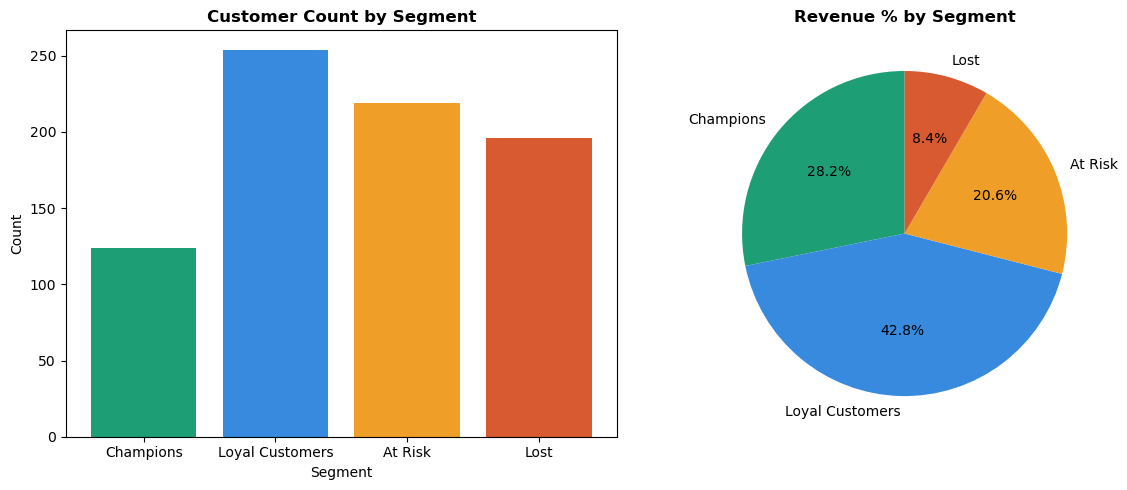

In [13]:
# Statistical Summary by Level
seg_summary = rfm.groupby('segment_rfm').agg(
    count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()
seg_summary['revenue_pct'] = (seg_summary['total_revenue'] / 
                               seg_summary['total_revenue'].sum() * 100).round(1)
print(seg_summary.round(1))

# Chart: Customer Count and Revenue Share by Tier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'Champions': '#1D9E75', 'Loyal Customers': '#378ADD', 
          'At Risk': '#EF9F27', 'Lost': '#D85A30'}
seg_order = ['Champions', 'Loyal Customers', 'At Risk', 'Lost']
seg_summary = seg_summary.set_index('segment_rfm').loc[seg_order].reset_index()

# customer ammount
axes[0].bar(seg_summary['segment_rfm'], seg_summary['count'],
            color=[colors[s] for s in seg_summary['segment_rfm']])
axes[0].set_title('Customer Count by Segment', fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')

# Revenue Share
axes[1].pie(seg_summary['revenue_pct'], 
            labels=seg_summary['segment_rfm'],
            colors=[colors[s] for s in seg_summary['segment_rfm']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Revenue % by Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

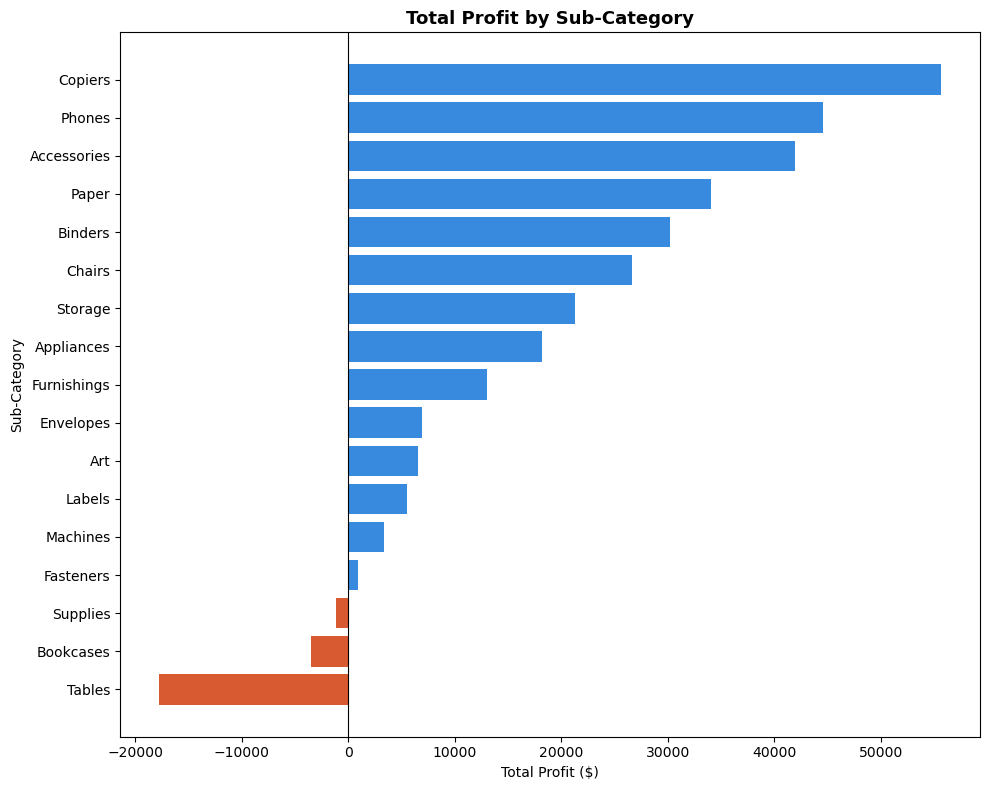

In [14]:
# Sub-category Profit Summary
sub_profit = df.groupby(['category', 'sub_category']).agg(
    total_profit=('profit', 'sum'),
    total_sales=('sales', 'sum'),
    order_count=('order_id', 'count')
).reset_index()
sub_profit['profit_margin'] = sub_profit['total_profit'] / sub_profit['total_sales']
sub_profit = sub_profit.sort_values('total_profit')

# Graph
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D85A30' if x < 0 else '#378ADD' for x in sub_profit['total_profit']]
ax.barh(sub_profit['sub_category'], sub_profit['total_profit'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Total Profit by Sub-Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
ax.set_ylabel('Sub-Category')

plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150, bbox_inches='tight')
plt.show()